# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [17]:
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('y_train_balanced.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

In [18]:
X_train

,Age,Income,Gender_encoded,Marital_Status_encoded,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Number_Childreen_1,Number_Childreen_2,Number_Childreen_3
0,26,45000.000000,0,1,1,False,False,False,False,False,False,False
1,29,27500.000000,0,1,1,False,False,True,False,False,False,False
2,25,62500.000000,0,1,1,True,False,False,False,False,False,False
3,29,68000.000000,0,0,0,False,True,False,False,False,True,False
4,31,65000.000000,1,1,1,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
247,27,36803.652916,0,1,1,False,False,True,False,False,False,False
248,27,37500.000000,0,1,1,False,False,True,False,False,False,False
249,28,29946.263487,0,1,1,False,False,True,False,False,False,False
250,27,35412.944984,0,1,1,False,False,True,False,False,False,False


In [6]:
y_train

,Credit_Score_encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


In [9]:
contagem_balan_train = y_train.value_counts()

contagem_balan_test = y_test.value_counts()

print('Balanceamento treino', contagem_balan_train)
print('Não balanceamente teste', contagem_balan_test)

Balanceamento treino Credit_Score_encoded
0                       84
2                       84
1                       84
Name: count, dtype: int64
Não balanceamente teste Credit_Score_encoded
1                       29
0                        6
2                        6
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

O algoritmo de 'árvore de decisão' é um modelo de Machine Learning, que realiza previsões de dados e também classifica dados. Para utilizá-lo precisa-se chamar o módulo 'DecisionTreeClassifier ' da biblioteca 'Sklearn'. Em seguida, após separar as bases em treino e teste, aplicamos os dados na árvore de decisão, e avalia-se as métricas como: acurácia, recall e precisão, para saber se o modelo está conseguindo fazer boas previsões com os dados e se ele está conseguindo generalizar bem para novos dados. Se o modelo não estiver com respostas tão boas pode-se fazer alterações nas configurações dos parâmetros dele, escolhendo as melhores features através do processo de poda da árvore. Também podemos fazer definir manualmente algumas características do próprio modelo.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [19]:
from sklearn.tree import DecisionTreeClassifier
arvore = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [23]:
#Analisando métricas
previsoes = arvore.predict(X_train)
print('Previsões para X_train:', previsoes)

Previsões para X_train: [0 2 0 0 0 1 1 1 0 1 1 1 0 0 1 1 0 1 2 1 1 1 1 1 0 1 1 2 1 0 1 1 1 1 1 1 1
 0 1 1 1 2 1 0 1 2 1 2 1 0 2 1 0 1 0 1 1 0 1 2 1 0 1 1 1 0 0 1 1 1 0 1 1 0
 1 1 1 2 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [24]:
y_train

,Credit_Score_encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


Pelo observado aqui a árvore de decisão fez excelentes previsões.

In [25]:
acuracia = accuracy_score(y_train, previsoes)
print('Acurácia', acuracia)

Acurácia 1.0


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [27]:
from sklearn.metrics import accuracy_score, classification_report
previsao = arvore.predict(X_test)
acuracia = accuracy_score(y_test, previsao)
print("Acurácia:", acuracia)

Acurácia: 0.9512195121951219


A acurácia para os dados de teste foram bem altas, apesar de terem sido menores que nos dados de treino. 

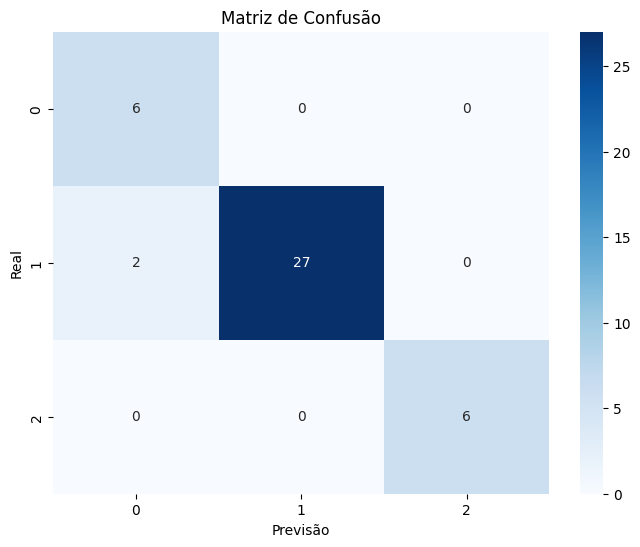

In [30]:
matriz_confusao = confusion_matrix(y_test, previsao)

# Gerando matriz de confusão
labels = np.unique(y_test)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=[str(label) for label in labels],
            yticklabels=[str(label) for label in labels])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

Na Matriz de Confusão podemos observar que os dados estão quase perfeitamente previstos. 

In [31]:
relatorio = classification_report(y_test, previsao)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.93      0.96        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



* Para a classe 0: A precisão foi de 0.75 (ou 75%), o que implica que de 75% das amostras previstas como pertencentes à classe 0 são realmente 0.
* Para a classe 1: A precisão foi de 1.00 (ou 100%), indicando que todas as amostras previstas como pertencentes à classe 1 realmente são da classe 1.
* Para a classe 2: A precisão foi de 1.00 (ou 100%), indicando que todas as amostras previstas como pertencentes à classe 2 realmente são da classe 2.

* Para a classe 0: A revocação foi de 1.00 (ou 100%), indicando que o modelo identificou corretamente todas das amostras da classe 0.
* Para a classe 1: A revocação é de 0.93 (ou 93%), indicando que o modelo identificou corretamente 93% das amostras da classe 1.
* Para a classe 1: A revocação é de 1.00 (ou 100%), indicando que o modelo identificou corretamente todas das amostras da classe 2.

* A acurácia total foi de 0.95 (ou 95%) o que significa quee 95% de todas as previsões feitas pelo modelo estão corretas.

* A média ponderada para a precisão é de  0.96 (ou 96%), e para o recall é de 0.95 (ou 95%). Essa média ponderada leva em conta o desequilíbrio das classes, ponderando as métricas com base no número de amostras em cada classe.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

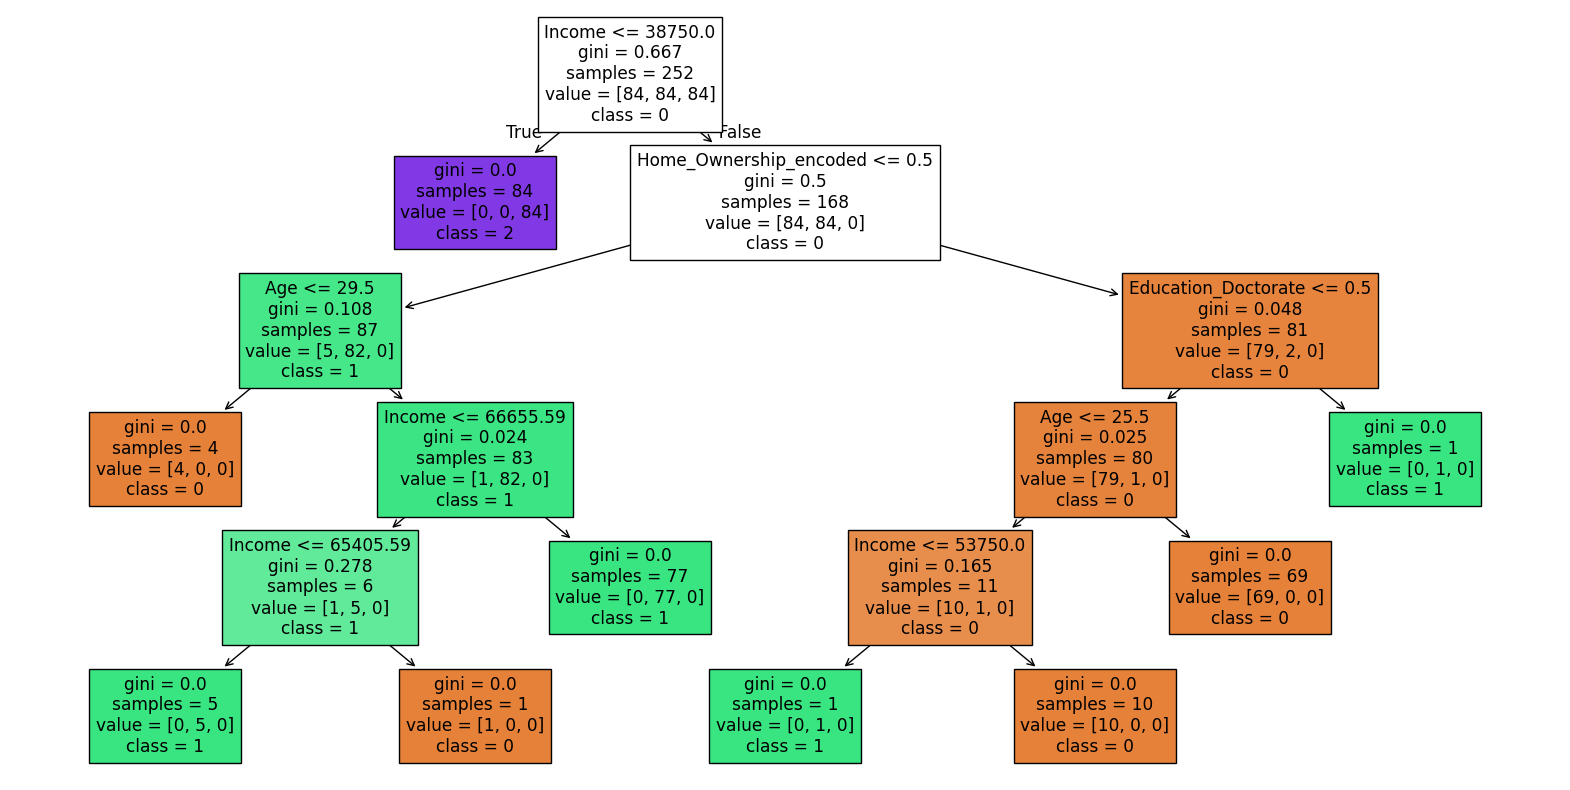

In [35]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(arvore, filled=True, feature_names=X_train.columns, class_names=[str(label) for label in labels])
plt.show()

A profundidade da árvore é medida pelo maior número de perguntas feitas em sequência até chegar a resposta. Na imagem podemos ver que a profundidade é de 5.

# 6) Identifique as 2 principais features do modelo.


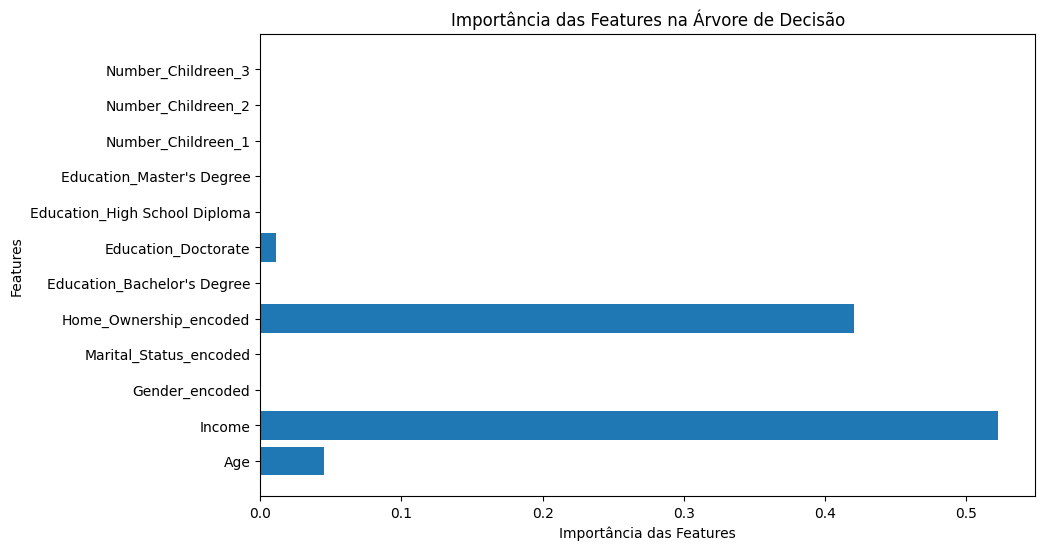

In [37]:
# Obtendo a importância das características do modelo de árvore de decisão
features_importantes = arvore.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, features_importantes)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

As features (características) mais importantes são 'home_owner_encoded' e 'income'.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [38]:
X_train_reduzido = X_train[['Home_Ownership_encoded', 'Income']]
X_test_reduzido = X_test[['Home_Ownership_encoded', 'Income']]

In [44]:
arvore_reduzida = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_reduzida.fit(X_train_reduzido, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [46]:
previsoes_reduzido = arvore_reduzida.predict(X_test_reduzido)

In [47]:
relatorio = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



* Para a classe 0: o valor da precisão  e recall foi de 0.83 (ou 83%), o que indica que 87% das amostras previstos para 0 são realmente de 0;
* Para a classe 1: o valor da precisão e recall foi de 0.97 (ou 97%), o que indica que 97% das amostra previstas para 1 são realmente de 1;
* Para a classe 2: o valor da precisão e recall foi de 1.00 (ou 100%0], o que  indica que todas as amostra previstas para 2 são realmente de 2.

* A acurácia global foi de 0.95 (ou 95%). E a média ponderada foi de 0.95 (ou 95%) para precisão e recall.

Pelo que observei nos dados das duas árvore (a que está com todos os dados e a podada), houve variações em algumas métricas, causando melhoras em umas e pioras em outras. Por exemplo: no primeiro modelo a precisão estava de 75% para a classe zero e no segundo modelo de 83%, já para a classe 1, o primeiro modelo deu um resultado de 100% na métrica da precisão, mas no segundo foi de 97%, semelhanças foram observadas para outras métricas, o que implica que podar essa árvore não fez tanta diferença em relação ao resultado ao total. 

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

No algoritmo de Naive Bayes, a acurácia foi de 97%, e na árvore de decisão foi de 95% (ambos para dados de teste). O recall em Naive Bayes foi de 94% e na árvore de decisão teve a média geral de 93% e ponderada de 95%. Pelo que podemos observar o modelo de Naive Bayes foi melhor, mas essa melhoria é baixa. Ambos são bons para os dados, mas talvez utilizar Naive Bayes seja melhor.